# Lab 6 - Segmentación de prendas con SegFormer

En este lab usaremos el modelo SegFormer-B2 entrenado para prendas de vestir y haremos inferencia en el dataset ModaNet.

**Objetivos**
1) Descargar y explorar el dataset ModaNet.
2) Cargar el modelo SegFormer y ejecutar inferencia.
3) Calcular Dice por clase.

## Setup de librerías y dispositivo

In [1]:
import os, json, glob, random
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


## Descargar dataset

En este caso utilizaremos el dataset de segmentación de prendas [ModaNet](https://github.com/eBay/modanet), el cual tiene las siguientes etiquetas:

| Label | Description |
| --- | --- |
| 1 | bag |
| 2 | belt |
| 3 | boots |
| 4 | footwear |
| 5 | outer |
| 6 | dress |
| 7 | sunglasses |
| 8 | pants |
| 9 | top |
|10 | shorts |
|11 | skirt |
|12 | headwear |
|13 | scarf & tie |

In [2]:
!wget "https://www.dropbox.com/scl/fo/g0or9rc44z7ey8oj8b5gv/AJnHmMLpYvYNYj-DK8Vf5oA/annotations-seg.tar?rlkey=l61rkqa63s9kv57bh1tp1oiie&dl=0" -q -O annotations-seg.tar
!wget "https://www.dropbox.com/scl/fo/g0or9rc44z7ey8oj8b5gv/AMvjsHNsh406QE1R7fhEhG8/images_modanet.tar?rlkey=l61rkqa63s9kv57bh1tp1oiie&dl=0" -q -O images_modanet.tar

# Descomprimir dataset
DATA_ROOT = Path("/content/modanet")
!mkdir {DATA_ROOT}
!tar -xf annotations-seg.tar -C /content/modanet
!tar -xf images_modanet.tar -C /content/modanet

## Explorar dataset

Las etiquetas de este dataset están en formato json y contienen la siguiente información:
```
annotation{
  'category_id': str,
  'bbox': {x,y,width,height},
  'segmentation': [[polygon]],
  'iscrowd': int
}
```

In [3]:
IM_DIR = DATA_ROOT / 'images'
ANN_DIR = DATA_ROOT / 'annotations-seg'

modanet_id2label = {1:"bag", 2:"belt", 3:"boots", 4:"footwear", 5:"outer",
                   6:"dress", 7:"sunglasses", 8:"pants", 9:"top", 10:"shorts",
                   11:"skirt", 12:"headwear", 13:"scarf & tie"}

def load_annotations(json_path):
    """
    Lee un JSON con lista de objetos:
      [{"category_id":"5", "bounding-box": {...}}, ...], "segmentation":[[x1,y1,x2,y2,...]], "iscrowd":0
    Retorna la lista tal cual (normalizando category_id a int).
    """
    with open(json_path, 'r') as f:
        anns = json.load(f)
    # Normalizamos category_id a int cuando venga como string
    for a in anns:
        if isinstance(a.get('category_id', None), str):
            try:
                a['category_id'] = int(a['category_id'])
            except Exception:
                pass
    return anns

def polygons_to_mask(img_size_hw, anns, background_id=0):
    """
    Rasteriza polígonos a una máscara HxW de IDs de clase.
    - img_size_hw: (H, W)
    - anns: lista de anotaciones. Cada anotación puede tener múltiples polígonos en 'segmentation'
    Devuelve: mask (np.int64) de tamaño HxW con IDs de clase.
    """
    H, W = img_size_hw
    mask = Image.new('I', (W, H), color=background_id)  # modo 'I' = 32-bit entero
    draw = ImageDraw.Draw(mask)

    for ann in anns:
        cat = int(ann.get('category_id', 0))
        seg = ann.get('segmentation', [])
        for poly in seg:
            # poly es [x1,y1,x2,y2,...] -> convertir a lista de tuplas (x,y)
            if not poly:
                continue
            pts = list(zip(poly[0::2], poly[1::2]))
            # Dibujar polígono relleno con el ID de clase
            draw.polygon(pts, fill=cat)
    return np.array(mask, dtype=np.int64)

def color_palette(n, seed=10):
    rng = np.random.RandomState(seed)
    return [tuple(int(x) for x in rng.randint(0,255,3)) for _ in range(n)]

PALETTE = color_palette(20)

def overlay_mask(img_rgb, mask_ids, alpha=0.5, ignore_ids=(0,)):
    """
    Superpone la máscara (IDs) sobre la imagen RGB.
    ignore_ids: IDs que no se colorean (e.g., 0 = fondo)
    """
    color = np.zeros_like(img_rgb)
    uniq = np.unique(mask_ids)
    for cid in uniq:
        if cid in ignore_ids:
            continue
        color[mask_ids == cid] = PALETTE[int(cid) % len(PALETTE)]
    return cv2.addWeighted(img_rgb, 1-alpha, color, alpha, 0)

def create_legend(pred_seg, id2label):
    present = [int(c) for c in np.unique(pred_seg) if c != 0]  # sin fondo
    patches = []
    for cid in present:
        r,g,b = PALETTE[cid % len(PALETTE)]
        patches.append(mpatches.Patch(color=(r/255, g/255, b/255), label=id2label.get(cid)))
    return patches

def show_samples(n=4, alpha=0.5):
    picks = random.sample(json_files, k=min(n, len(json_files)))
    fig, axes = plt.subplots(len(picks), 2, figsize=(8, 4*len(picks)))
    if len(picks) == 1:
        axes = np.array([axes])  # normalizar shape

    for row, jp in enumerate(picks):
        anns = load_annotations(jp)
        stem = jp.stem  # nombre base sin .json
        # Buscar imagen con ese stem
        img_path = None
        for ext in ('.jpg', '.jpeg', '.png'):
            p = IM_DIR / f"{stem}{ext}"
            if p.exists():
                img_path = p
                break

        img = Image.open(img_path).convert('RGB')
        img_np = np.array(img)
        H, W = img_np.shape[:2]
        mask = polygons_to_mask((H, W), anns)

        vis = overlay_mask(img_np, mask, alpha=alpha)
        patches = create_legend(mask, modanet_id2label)

        axes[row, 0].imshow(img_np)
        axes[row, 0].set_title(f"Imagen: {img_path.name}")
        axes[row, 0].axis('off')
        axes[row, 1].imshow(vis)
        axes[row, 1].set_title("Segmentación")
        axes[row, 1].axis('off')
        if patches:
          axes[row, 1].legend(handles=patches, loc='lower right', frameon=True, fontsize=8)

    plt.tight_layout()
    plt.show()

Encontrados 52254 archivos de anotaciones


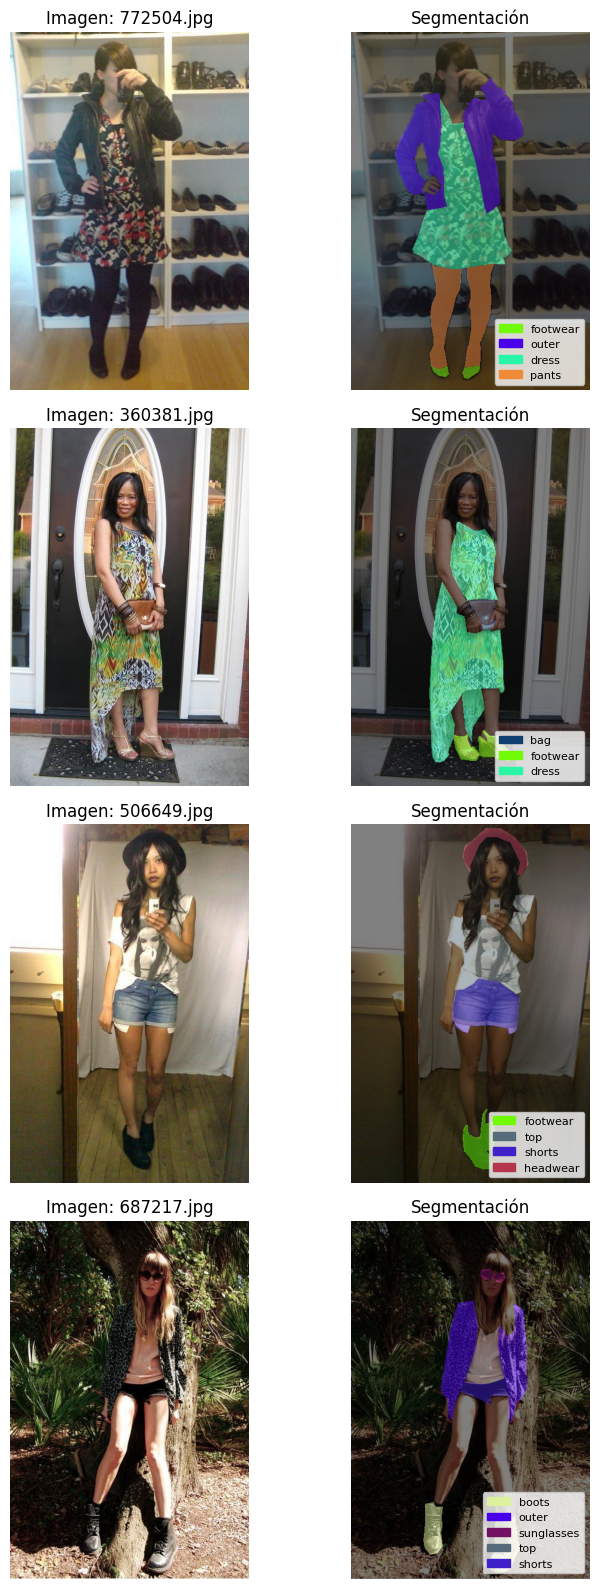

In [10]:
# Mostrar algunas imágenes con su segmentación

json_files = sorted(ANN_DIR.glob('*.json'))
print(f"Encontrados {len(json_files)} archivos de anotaciones")

show_samples(n=4, alpha=0.5)

## Cargar modelo SegFormer

In [5]:
from transformers import SegformerImageProcessor, AutoModelForSemanticSegmentation

processor = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
model = AutoModelForSemanticSegmentation.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

In [6]:
# Numero de etiquetas y sus valores
num_labels = model.config.num_labels
model_id2label = model.config.id2label

print('num_labels:', num_labels)
print('id2label:', model_id2label)

num_labels: 18
id2label: {0: 'Background', 1: 'Hat', 2: 'Hair', 3: 'Sunglasses', 4: 'Upper-clothes', 5: 'Skirt', 6: 'Pants', 7: 'Dress', 8: 'Belt', 9: 'Left-shoe', 10: 'Right-shoe', 11: 'Face', 12: 'Left-leg', 13: 'Right-leg', 14: 'Left-arm', 15: 'Right-arm', 16: 'Bag', 17: 'Scarf'}


## Inferencia en una imagen de ejemplo

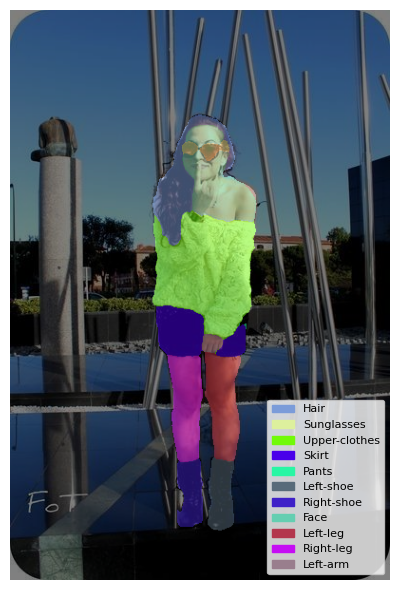

In [11]:
image = Image.open(IM_DIR / "1000033.jpg")
img_np = np.array(image.convert("RGB"))
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
logits = outputs.logits.cpu()

# Escalar salida a tamaño original
upsampled_logits = F.interpolate(
    logits, size=image.size[::-1], mode="bilinear", align_corners=False
)

pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()

# overlay
out = overlay_mask(img_np, pred_seg, alpha=0.5)

# Crear leyenda a partir de las clases presentes
patches = create_legend(pred_seg, model_id2label)

# Plot con leyenda al lado
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(out)
ax.axis('off')
if patches:
    ax.legend(handles=patches, loc='lower right', frameon=True, fontsize=8)
plt.tight_layout()
plt.show()

## Inferencia en imagen subida

Saving istockphoto-1035693082-612x612.jpg to istockphoto-1035693082-612x612 (1).jpg


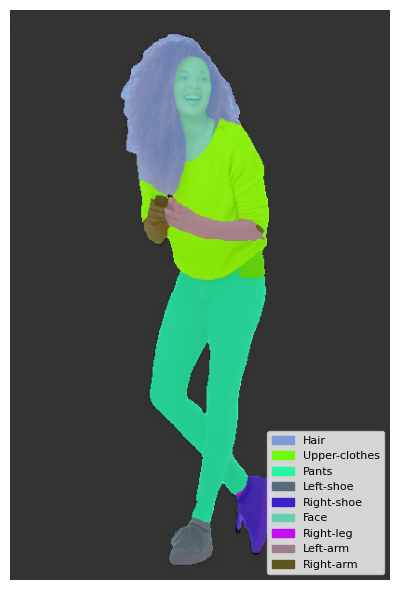

In [13]:
from google.colab import files

uploaded = files.upload()
IMG_PATH = list(uploaded.keys())[0]
image = Image.open(IMG_PATH)
img_np = np.array(image.convert("RGB"))
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
logits = outputs.logits.cpu()
upsampled_logits = F.interpolate(
    logits, size=image.size[::-1], mode="bilinear", align_corners=False
)
pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()
out = overlay_mask(img_np, pred_seg, alpha=0.8)
patches = create_legend(pred_seg, model_id2label)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(out)
ax.axis('off')
if patches:
    ax.legend(handles=patches, loc='lower right', frameon=True, fontsize=8)
plt.tight_layout()
plt.show()

## Mapeo de etiquetas

In [14]:
# - Clases sin equivalente se mapean a 0 (fondo).
# - Left/Right-shoe -> footwear(4)
# - Upper-clothes -> top(9)
# - Hat -> headwear(12)
# - Scarf -> scarf & tie(13)
# - Belt, Bag, Skirt, Pants, Dress, Sunglasses directos
# - boots(3), outer(5) y shorts(10) no existen en el modelo => quedarán sin predicción (0)

model_to_modanet = {
    0:0,                # Background
    1:12,               # Hat -> headwear
    2:0,                # Hair -> (ignorar)
    3:7,                # Sunglasses
    4:9,                # Upper-clothes -> top
    5:11,               # Skirt
    6:8,                # Pants
    7:6,                # Dress
    8:2,                # Belt
    9:4, 10:4,          # Left/Right-shoe -> footwear
    11:0,               # Face -> (ignorar)
    12:0, 13:0,         # Left/Right-leg -> (ignorar)
    14:0, 15:0,         # Left/Right-arm -> (ignorar)
    16:1,               # Bag
    17:13               # Scarf -> scarf & tie
}

def remap_pred_to_modanet(pred_mask_model, mapping):
    """pred_mask_model: HxW con IDs del modelo -> HxW con IDs de ModaNet."""
    max_id = int(pred_mask_model.max())
    lut = np.zeros(max(max_id+1, max(mapping.keys())+1), dtype=np.int32)
    for k,v in mapping.items():
        lut[k] = v
    return lut[pred_mask_model]

Saving istockphoto-1035693082-612x612.jpg to istockphoto-1035693082-612x612 (2).jpg


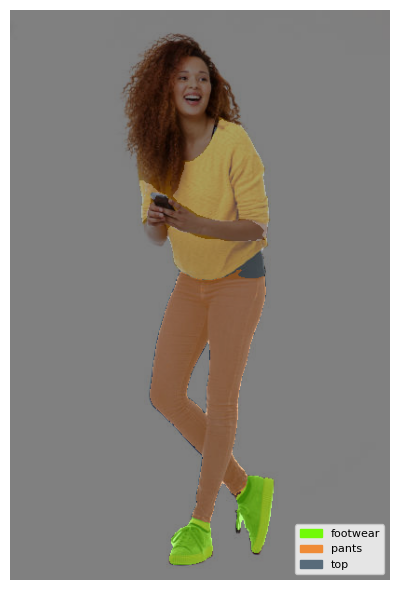

In [15]:
uploaded = files.upload()
IMG_PATH = list(uploaded.keys())[0]
image = Image.open(IMG_PATH)
img_np = np.array(image.convert("RGB"))
inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = model(**inputs)
logits = outputs.logits.cpu()
upsampled_logits = F.interpolate(
    logits, size=image.size[::-1], mode="bilinear", align_corners=False
)
pred_seg = upsampled_logits.argmax(dim=1)[0].numpy()
# Remap modelo -> ModaNet
pred_seg_modanet = remap_pred_to_modanet(pred_seg, model_to_modanet)
out = overlay_mask(img_np, pred_seg_modanet, alpha=0.5)
patches = create_legend(pred_seg_modanet, modanet_id2label)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(out)
ax.axis('off')
if patches:
    ax.legend(handles=patches, loc='lower right', frameon=True, fontsize=8)
plt.tight_layout()
plt.show()

## Tarea

Para la primera parte de la tarea tendrán que calcular el Dice por clase de cada imagen del dataset y presentar un gráfico de barras de los resultados promedio de cada clase. Para esto deben ocupar el mapeo mencionado más arriba e ir iterando y guardando los resultados de cada imagen para que luego puedan calcular un promedio final por clase y mostrar el gráfico solicitado. Es importante que el Dice solo se calcule en los labels del ground truth de cada imagen.

Para la segunda parte, necesitarán usar el encoder Dinov3 que usaron en la tarea anterior y el módulo `SegformerModel` de `transformers` como encoder para extraer features de las imágenes del dataset. Esta vez los features deben ser enmascarados con la región a codificar. Para esto, tendrán que interpolar cada máscara del ground truth a la resolución del feature map extraido de cada encoder (usar `F.interpolate` con `mode='nearest'`) y luego utilizar el promedio de los patches de esa clase como vector a visualizar. Con todos estos vectores calculados, deberán utilizar UMAP para visualizar el espacio de las prendas con cada encoder por separado.

In [16]:
from transformers import SegformerImageProcessor, SegformerModel

processor_seg = SegformerImageProcessor.from_pretrained("mattmdjaga/segformer_b2_clothes")
segformer = SegformerModel.from_pretrained("mattmdjaga/segformer_b2_clothes").to(device)

/usr/local/lib/python3.12/dist-packages/transformers/image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


### Dinov3

In [34]:
!pip install -q torchmetrics
!git clone https://github.com/facebookresearch/dinov3.git
!gdown --id 1Fznrc_pDwp7iaUBhAoWUKPI1vsGpHy8m

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1Fznrc_pDwp7iaUBhAoWUKPI1vsGpHy8m
From (redirected): https://drive.google.com/uc?id=1Fznrc_pDwp7iaUBhAoWUKPI1vsGpHy8m&confirm=t&uuid=f9a4a506-cae9-49ee-a431-3f6d10042a88
To: /content/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth
100% 343M/343M [00:01<00:00, 251MB/s]


In [42]:
import torch
from torchvision import transforms

dinov3 = torch.hub.load("/content/dinov3", 'dinov3_vitb16', source='local', weights="/content/dinov3_vitb16_pretrain_lvd1689m-73cec8be.pth")
dinov3 = dinov3.to(device)

In [48]:
inputs_seg = processor_seg(images=image, return_tensors="pt").to(device)

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

image = image.convert("RGB")
img_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    outputs_seg = segformer(**inputs_seg)
    outputs_dino = dinov3(img_tensor, is_training=True)['x_norm_patchtokens']

In [52]:
print(outputs_dino.shape)
print(outputs_dino[0].reshape(16, 16, 768).shape)

torch.Size([1, 256, 768])
torch.Size([16, 16, 768])


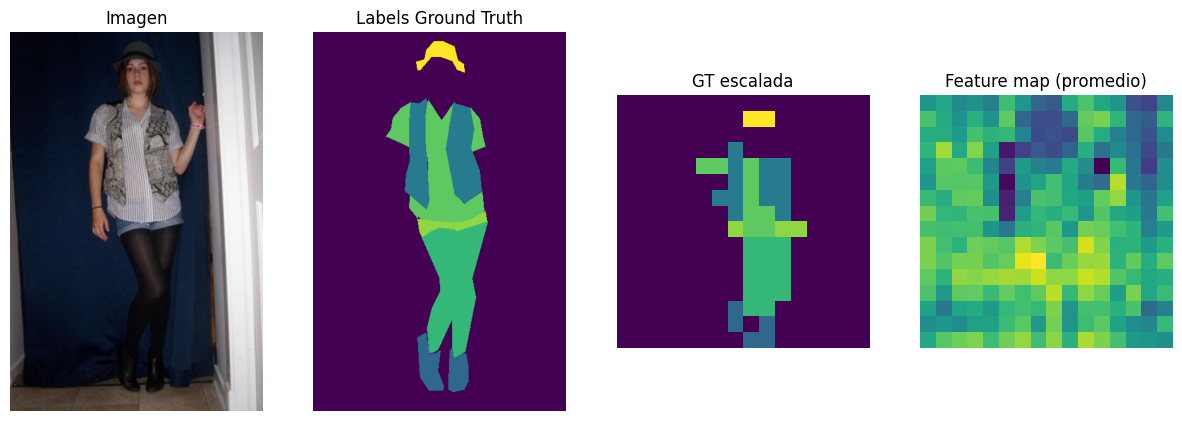

In [55]:
img_path = "/content/modanet/images/13.jpg"
ann_path = "/content/modanet/annotations-seg/13.json"

image = Image.open(img_path).convert("RGB")
img_np = np.array(image)
H, W = img_np.shape[:2]
anns = load_annotations(ann_path)
gt_mask = polygons_to_mask((H, W), anns)
gt_tensor = torch.tensor(gt_mask).float().unsqueeze(0).unsqueeze(0)
resized_gt_mask = F.interpolate(gt_tensor, size=(16, 16), mode="nearest").squeeze().long().numpy()

img_tensor = transform(image).unsqueeze(0).to(device)
with torch.no_grad():
    outputs_dino = dinov3(img_tensor, is_training=True)['x_norm_patchtokens']

patch_features_dino = outputs_dino[0].reshape(16, 16, 768)
patch_features_dino = patch_features_dino.squeeze().mean(-1).cpu().numpy()

fig, axs = plt.subplots(1, 4, figsize=(15, 8))
axs[0].imshow(image)
axs[0].axis('off')
axs[0].set_title("Imagen")
axs[1].imshow(gt_mask)
axs[1].axis('off')
axs[1].set_title("Labels Ground Truth")
axs[2].imshow(resized_gt_mask)
axs[2].axis('off')
axs[2].set_title("GT escalada")
axs[3].imshow(patch_features_dino)
axs[3].axis('off')
axs[3].set_title("Feature map (promedio)")
plt.show()